# Controlled Scaling Diagnostics

Purpose: before running any FERM specification, inspect whether the candidate features are mechanically tied to population scale.

This notebook checks:

1. GDP per capita 2018 vs population 2021.
2. SCI 2021 vs origin population, destination population, and origin-destination population product.
3. Whether the apparent feature signal could be mostly a population-size artifact.


In [1]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

ROOT = Path(".")
os.environ.setdefault("MPLCONFIGDIR", str((ROOT / ".matplotlib-cache").resolve()))
FIG_DIR = ROOT / "outputs" / "scaling_diagnostics"
FIG_DIR.mkdir(parents=True, exist_ok=True)

POP_YEAR = 2021
GDP_YEAR = 2018
SCI_YEAR = 2021
SCI_COL = "scaled_sci_2021"

POP_PATH = ROOT / "data" / "population" / "API_SP.POP.TOTL_DS2_en_csv_v2_61.csv"
GDP_PATH = ROOT / "data" / "features" / "API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46.csv"
GRAVITY_PATH = ROOT / "Gravity_csv_V202211" / "Gravity_V202211_bilateral_nonbinary.csv"
COUNTRIES_PATH = ROOT / "Gravity_csv_V202211" / "Countries_V202211.csv"

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 220,
    "axes.grid": True,
    "font.size": 11,
})


def savefig(name: str):
    path = FIG_DIR / f"{name}.png"
    plt.savefig(path, bbox_inches="tight")
    print(f"saved: {path}")


def log10(x):
    return np.log10(np.asarray(x, dtype=float))


In [2]:
def load_world_bank_year(path: Path, year: int, value_col: str) -> pd.DataFrame:
    df = pd.read_csv(path, skiprows=4)
    out = df[["Country Name", "Country Code", str(year)]].copy()
    out = out.rename(columns={
        "Country Name": "country_name",
        "Country Code": "iso3",
        str(year): value_col,
    })
    out["iso3"] = out["iso3"].astype(str).str.strip().str.upper()
    out[value_col] = pd.to_numeric(out[value_col], errors="coerce")
    return out.dropna(subset=["iso3", value_col]).drop_duplicates("iso3")


def corr_row(x, y, x_name, y_name):
    mask = np.isfinite(x) & np.isfinite(y)
    x = np.asarray(x)[mask]
    y = np.asarray(y)[mask]
    return {
        "x": x_name,
        "y": y_name,
        "pearson": stats.pearsonr(x, y).statistic if len(x) > 2 else np.nan,
        "spearman": stats.spearmanr(x, y).correlation if len(x) > 2 else np.nan,
        "n": int(len(x)),
    }

pop = load_world_bank_year(POP_PATH, POP_YEAR, f"population_{POP_YEAR}")
gdp = load_world_bank_year(GDP_PATH, GDP_YEAR, f"gdp_per_capita_{GDP_YEAR}")
countries = pd.read_csv(COUNTRIES_PATH)[["iso3", "country"]].drop_duplicates("iso3")

country = (
    pop.merge(gdp, on="iso3", how="inner", suffixes=("_pop", "_gdp"))
       .merge(countries, on="iso3", how="inner")
)
country = country[(country[f"population_{POP_YEAR}"] > 0) & (country[f"gdp_per_capita_{GDP_YEAR}"] > 0)].copy()

print(f"Country-level rows with population and GDP per capita: {len(country):,}")
display(country[["iso3", "country", f"population_{POP_YEAR}", f"gdp_per_capita_{GDP_YEAR}"]].head())


Country-level rows with population and GDP per capita: 207


,iso3,country,population_2021,gdp_per_capita_2018
0,ABW,Aruba,107700.0,30082.158423
1,AFG,Afghanistan,40000412.0,491.337221
2,AGO,Angola,34532429.0,2860.093648
3,ALB,Albania,2489762.0,5897.654526
4,AND,Andorra,78364.0,42819.757746


In [3]:
gravity = pd.read_csv(
    GRAVITY_PATH,
    usecols=["year", "iso3_o", "iso3_d", SCI_COL],
)

# SCI is a 2021 variable repeated in the Gravity panel; keep one dyadic cross-section.
sci = gravity[gravity["year"] == SCI_YEAR].dropna(subset=[SCI_COL]).copy()
sci = sci[sci[SCI_COL] > 0].copy()

pop_lookup = pop[["iso3", f"population_{POP_YEAR}"]].copy()
sci = sci.merge(
    pop_lookup.rename(columns={"iso3": "iso3_o", f"population_{POP_YEAR}": "pop_o"}),
    on="iso3_o",
    how="inner",
)
sci = sci.merge(
    pop_lookup.rename(columns={"iso3": "iso3_d", f"population_{POP_YEAR}": "pop_d"}),
    on="iso3_d",
    how="inner",
)
sci = sci[(sci["pop_o"] > 0) & (sci["pop_d"] > 0)].copy()
sci["pop_product"] = sci["pop_o"] * sci["pop_d"]
sci["log_sci"] = log10(sci[SCI_COL])
sci["log_pop_o"] = log10(sci["pop_o"])
sci["log_pop_d"] = log10(sci["pop_d"])
sci["log_pop_product"] = log10(sci["pop_product"])

print(f"SCI dyads with population: {len(sci):,}")
print(f"SCI range: {sci[SCI_COL].min():,.0f} to {sci[SCI_COL].max():,.0f}")
display(sci[["iso3_o", "iso3_d", SCI_COL, "pop_o", "pop_d"]].head())


SCI dyads with population: 30,450
SCI range: 57 to 37,967,668


,iso3_o,iso3_d,scaled_sci_2021,pop_o,pop_d
0,ABW,AGO,1344.0,107700.0,34532429.0
1,ABW,ALB,1849.0,107700.0,2489762.0
2,ABW,ARE,3998.0,107700.0,9575152.0
3,ABW,ARG,7185.0,107700.0,45312281.0
4,ABW,ARM,339.0,107700.0,2962300.0


In [4]:
summary_rows = []
summary_rows.append(corr_row(
    log10(country[f"population_{POP_YEAR}"]),
    log10(country[f"gdp_per_capita_{GDP_YEAR}"]),
    f"log10 population {POP_YEAR}",
    f"log10 GDP per capita {GDP_YEAR}",
))
for x_col, label in [
    ("log_pop_o", "log10 origin population"),
    ("log_pop_d", "log10 destination population"),
    ("log_pop_product", "log10 origin * destination population"),
]:
    summary_rows.append(corr_row(
        sci[x_col],
        sci["log_sci"],
        label,
        "log10 SCI 2021",
    ))

correlation_summary = pd.DataFrame(summary_rows)
display(correlation_summary)
correlation_summary.to_csv(FIG_DIR / "scaling_correlation_summary.csv", index=False)


,x,y,pearson,spearman,n
0,log10 population 2021,log10 GDP per capita 2018,-0.339404,-0.330109,207
1,log10 origin population,log10 SCI 2021,-0.095395,-0.081793,30450
2,log10 destination population,log10 SCI 2021,-0.095395,-0.081793,30450
3,log10 origin * destination population,log10 SCI 2021,-0.135299,-0.104622,30450


saved: outputs/scaling_diagnostics/01_gdp_per_capita_vs_population.png


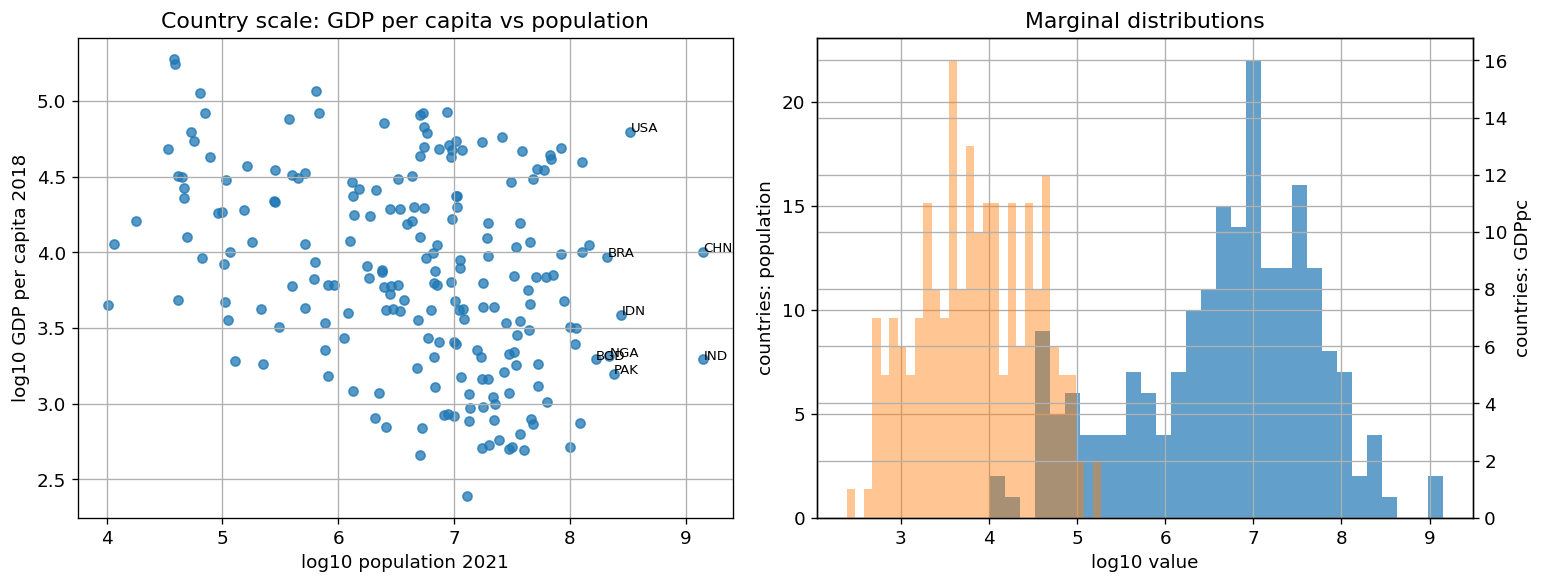

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(
    log10(country[f"population_{POP_YEAR}"]),
    log10(country[f"gdp_per_capita_{GDP_YEAR}"]),
    alpha=0.75,
    s=30,
)
for _, row in country.nlargest(8, f"population_{POP_YEAR}").iterrows():
    ax.annotate(row["iso3"], (np.log10(row[f"population_{POP_YEAR}"]), np.log10(row[f"gdp_per_capita_{GDP_YEAR}"])), fontsize=8)
ax.set_title("Country scale: GDP per capita vs population")
ax.set_xlabel(f"log10 population {POP_YEAR}")
ax.set_ylabel(f"log10 GDP per capita {GDP_YEAR}")

ax = axes[1]
ax.hist(log10(country[f"population_{POP_YEAR}"]), bins=30, alpha=0.7, label="population")
ax2 = ax.twinx()
ax2.hist(log10(country[f"gdp_per_capita_{GDP_YEAR}"]), bins=30, alpha=0.45, color="tab:orange", label="GDPpc")
ax.set_title("Marginal distributions")
ax.set_xlabel("log10 value")
ax.set_ylabel("countries: population")
ax2.set_ylabel("countries: GDPpc")

plt.tight_layout()
savefig("01_gdp_per_capita_vs_population")
plt.show()


/var/folders/23/tdv39nqs7c1260lvn9d3tf1r0000gn/T/ipykernel_34627/209319017.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


saved: outputs/scaling_diagnostics/02_sci_vs_population_hexbin.png


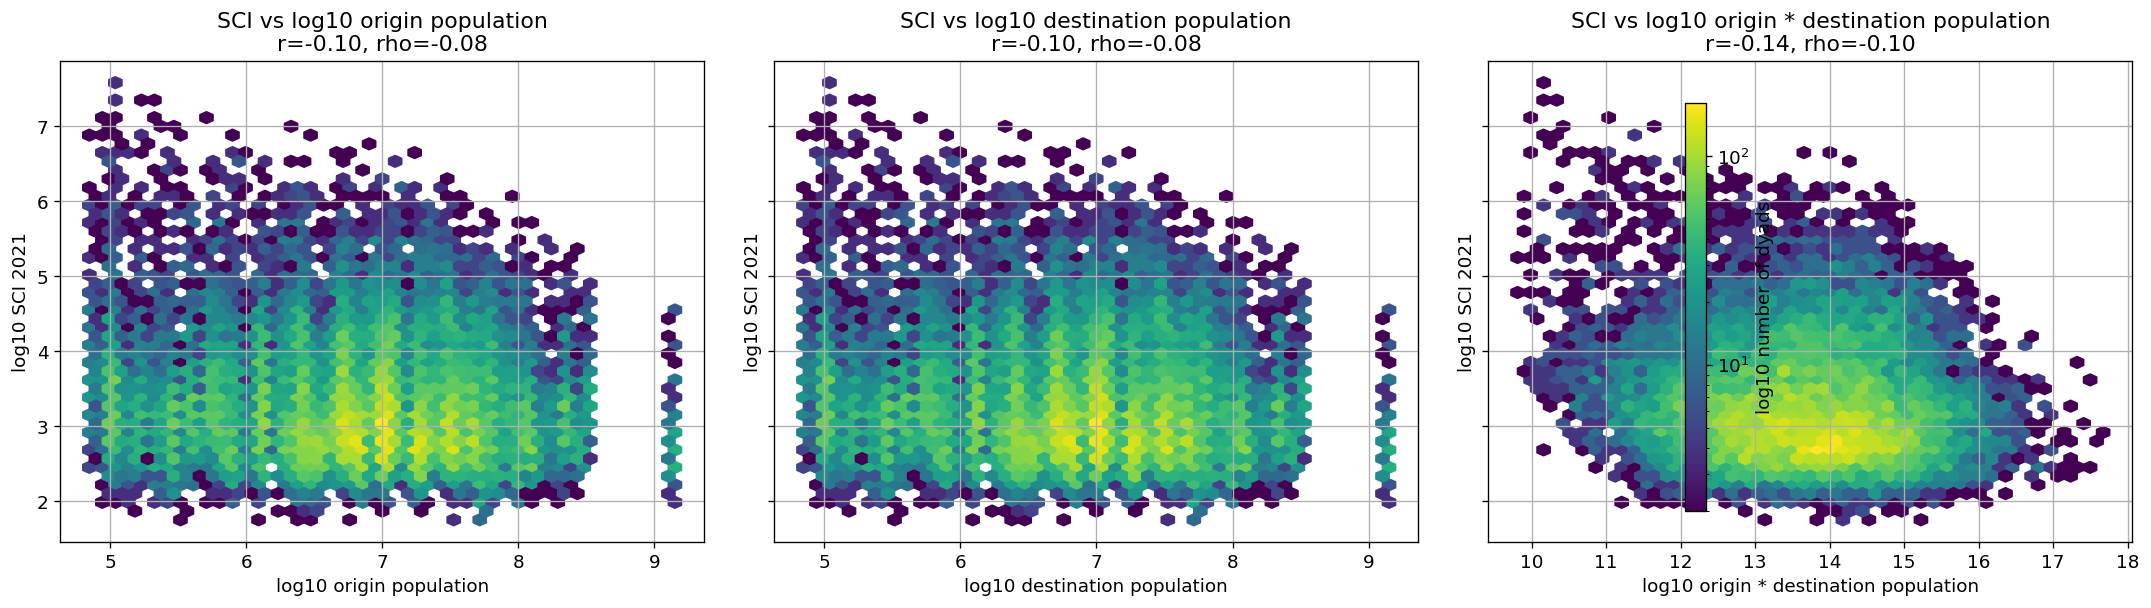

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2), sharey=True)

panels = [
    ("log_pop_o", "log10 origin population"),
    ("log_pop_d", "log10 destination population"),
    ("log_pop_product", "log10 origin * destination population"),
]

for ax, (x_col, label) in zip(axes, panels):
    hb = ax.hexbin(
        sci[x_col],
        sci["log_sci"],
        gridsize=45,
        mincnt=1,
        cmap="viridis",
        bins="log",
    )
    r = stats.pearsonr(sci[x_col], sci["log_sci"]).statistic
    rho = stats.spearmanr(sci[x_col], sci["log_sci"]).correlation
    ax.set_title(f"SCI vs {label}\nr={r:.2f}, rho={rho:.2f}")
    ax.set_xlabel(label)
    ax.set_ylabel("log10 SCI 2021")

cbar = fig.colorbar(hb, ax=axes, shrink=0.85)
cbar.set_label("log10 number of dyads")
plt.tight_layout()
savefig("02_sci_vs_population_hexbin")
plt.show()


saved: outputs/scaling_diagnostics/03_sci_binned_median_vs_population.png


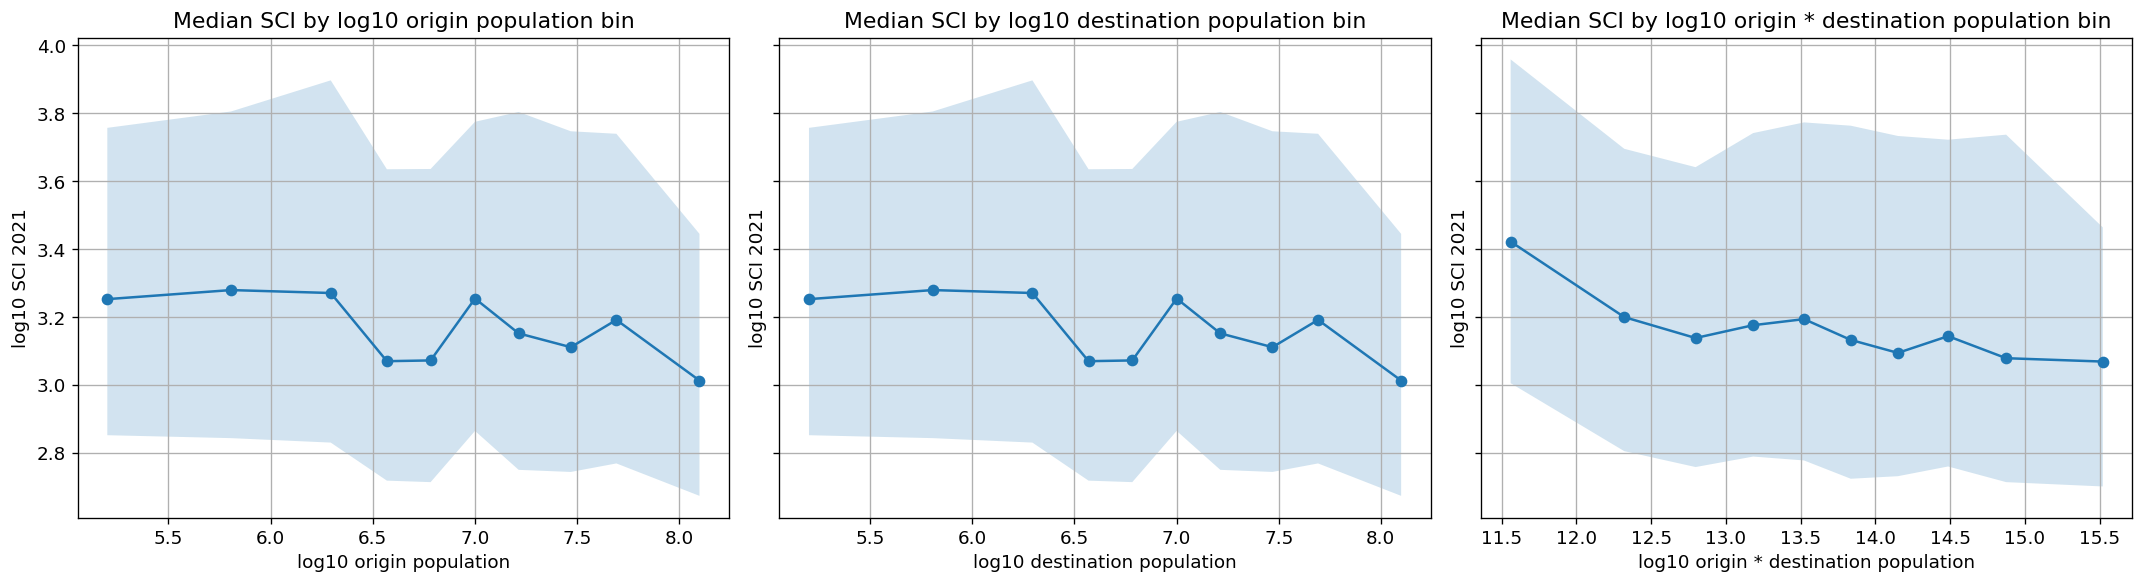

In [7]:
def binned_median(df, x_col, y_col, bins=8):
    tmp = df[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna().copy()
    tmp["bin"] = pd.qcut(tmp[x_col], q=bins, duplicates="drop")
    out = tmp.groupby("bin", observed=True).agg(
        x_mid=(x_col, "median"),
        y_median=(y_col, "median"),
        y_p25=(y_col, lambda s: s.quantile(0.25)),
        y_p75=(y_col, lambda s: s.quantile(0.75)),
        n=(y_col, "size"),
    ).reset_index()
    return out

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, (x_col, label) in zip(axes, panels):
    b = binned_median(sci, x_col, "log_sci", bins=10)
    ax.plot(b["x_mid"], b["y_median"], marker="o")
    ax.fill_between(b["x_mid"], b["y_p25"], b["y_p75"], alpha=0.2)
    ax.set_title(f"Median SCI by {label} bin")
    ax.set_xlabel(label)
    ax.set_ylabel("log10 SCI 2021")

plt.tight_layout()
savefig("03_sci_binned_median_vs_population")
plt.show()


## Reading Guide

- If GDP per capita and population were measuring the same scale effect, the first scatter would show a strong monotone relationship. A weak or moderate correlation means GDP per capita is not just country size.
- If SCI were mainly driven by population size, `log10 SCI` would rise strongly with origin population, destination population, or their product. Weak correlations suggest SCI contains corridor-specific social connectedness beyond population scale.
- The binned-median plots are more robust than raw scatter because SCI is extremely heavy-tailed.
